# ML Project - Diamond (Includes both - regression and Classification on single data set)

Dataset Description

The dataset features:

*Carat (weight of diamond)
*Color (quality grade)
*Clarity (purity level)
*Depth
*PricePerCt
*TotalPrice

# Objective

To predict diamond prices using regression models and classify diamonds into price categories using machine learning techniques.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline

# Regression setup (predict numeric values)

In [3]:
df = pd.read_csv("Diamond_Price_For Regression.csv")

In [4]:
df.head()

,Unnamed: 0,X,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
0,1,1,1.08,E,VS1,68.6,6693.3,7228.8
1,2,2,0.31,F,VVS1,61.9,3159.0,979.3
2,3,3,0.32,F,VVS1,60.8,3159.0,1010.9
3,4,4,0.33,D,IF,60.8,4758.8,1570.4
4,5,5,0.33,G,VVS1,61.5,2895.8,955.6


In [12]:
df = df.drop(columns=["X"])

In [13]:
df.head()

,Unnamed: 0,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
0,1,1.08,E,VS1,68.6,6693.3,7228.8
1,2,0.31,F,VVS1,61.9,3159.0,979.3
2,3,0.32,F,VVS1,60.8,3159.0,1010.9
3,4,0.33,D,IF,60.8,4758.8,1570.4
4,5,0.33,G,VVS1,61.5,2895.8,955.6


In [15]:
df = df.drop(columns=["Unnamed: 0"])

In [16]:
df.head()

,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
0,1.08,E,VS1,68.6,6693.3,7228.8
1,0.31,F,VVS1,61.9,3159.0,979.3
2,0.32,F,VVS1,60.8,3159.0,1010.9
3,0.33,D,IF,60.8,4758.8,1570.4
4,0.33,G,VVS1,61.5,2895.8,955.6


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Carat       307 non-null    float64
 1   Color       307 non-null    object 
 2   Clarity     307 non-null    object 
 3   Depth       307 non-null    float64
 4   PricePerCt  307 non-null    float64
 5   TotalPrice  307 non-null    float64
dtypes: float64(4), object(2)
memory usage: 14.5+ KB


,Carat,Depth,PricePerCt,TotalPrice
count,307.000000,307.000000,307.000000,307.000000
mean,0.973094,64.446580,6292.845277,7381.345928
std,0.493946,5.174909,2969.074593,8000.251838
min,0.310000,58.200000,1782.000000,853.300000
25%,0.630000,61.200000,4212.000000,2759.850000
50%,0.820000,62.000000,5197.500000,4243.800000
75%,1.220000,68.650000,7987.950000,9298.800000
max,3.350000,79.200000,17671.500000,56454.400000


# Converting Categorical data - Color and Clarity into numeric

In [20]:
df = pd.get_dummies(df, columns=["Color", "Clarity"], drop_first=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Carat         307 non-null    float64
 1   Depth         307 non-null    float64
 2   PricePerCt    307 non-null    float64
 3   TotalPrice    307 non-null    float64
 4   Color_E       307 non-null    bool   
 5   Color_F       307 non-null    bool   
 6   Color_G       307 non-null    bool   
 7   Clarity_SI1   307 non-null    bool   
 8   Clarity_SI2   307 non-null    bool   
 9   Clarity_SI3   307 non-null    bool   
 10  Clarity_VS1   307 non-null    bool   
 11  Clarity_VS2   307 non-null    bool   
 12  Clarity_VVS1  307 non-null    bool   
 13  Clarity_VVS2  307 non-null    bool   
dtypes: bool(10), float64(4)
memory usage: 12.7 KB


In [22]:
df.head()

,Carat,Depth,PricePerCt,TotalPrice,Color_E,Color_F,Color_G,Clarity_SI1,Clarity_SI2,Clarity_SI3,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
0,1.08,68.6,6693.3,7228.8,True,False,False,False,False,False,True,False,False,False
1,0.31,61.9,3159.0,979.3,False,True,False,False,False,False,False,False,True,False
2,0.32,60.8,3159.0,1010.9,False,True,False,False,False,False,False,False,True,False
3,0.33,60.8,4758.8,1570.4,False,False,False,False,False,False,False,False,False,False
4,0.33,61.5,2895.8,955.6,False,False,True,False,False,False,False,False,True,False


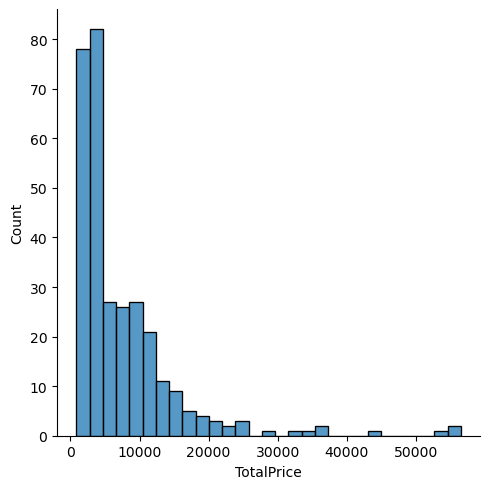

In [29]:
sns.displot(df['TotalPrice'])
plt.show()

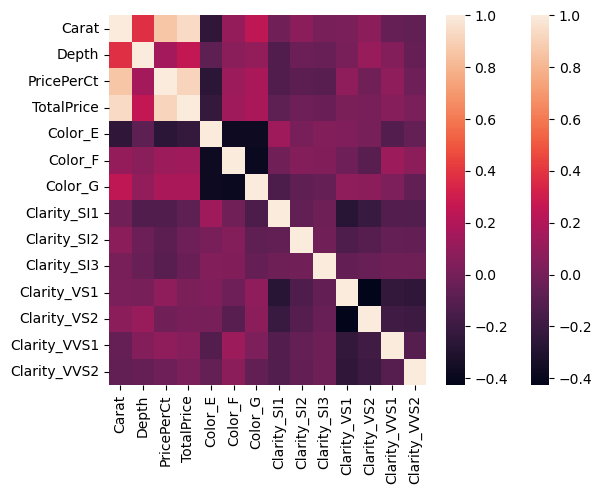

In [32]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

# REGRESSION SETUP

Define features & target

In [37]:
x = df.drop(columns=["TotalPrice"])
y = df["TotalPrice"]

# Train/Test Split

In [52]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

# Linear Regression

In [66]:
#Train Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [67]:
#Predict 
y_pred_lin = lin_reg.predict(x_test)

In [77]:
#Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_absolute_error(y_test, y_pred_lin))
print(mae_lin)
print(rmse_lin)

1490.098604193189
38.601795349351164


# Random Forest

In [71]:
lin_reg = RandomForestRegressor(random_state=42)
lin_reg.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [80]:
#Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred = lin_reg.predict(x_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_absolute_error(y_test, y_pred_lin)))

MAE: 276.270064516129
RMSE: 38.601795349351164


# Classification Setup

In [90]:
df["PriceCategory"] = pd.cut(
    df["TotalPrice"],
    bins=[0, 2000, 6000, df["TotalPrice"].max()],
    labels=["Low", "Medium", "High"]
)

In [91]:
x = df.drop(columns=["PriceCategory", "TotalPrice"])
y = df["PriceCategory"]

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [93]:
from sklearn.ensemble import RandomForestClassifier
clf_model = RandomForestClassifier()
clf_model.fit(x_train, y_train)

RandomForestClassifier()

# Evaluate

In [94]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred) )
print(classification_report(y_test, y_pred))

Accuracy: 0.9516129032258065
              precision    recall  f1-score   support

        High       1.00      0.92      0.96        25
         Low       1.00      0.90      0.95        10
      Medium       0.90      1.00      0.95        27

    accuracy                           0.95        62
   macro avg       0.97      0.94      0.95        62
weighted avg       0.96      0.95      0.95        62

